In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
def polynomial_regression_auto_mpg():
  auto_mpg = fetch_openml (name="autoMpg", version = 1, as_frame=True)
  data = auto_mpg.data
  target = auto_mpg.target
  data = data.dropna(subset=["horsepower"])
  target = target.loc[data.index]
  X_hp = data[["horsepower"]].astype(float)
  y_mpg = target.astype(float)
  return X_hp, y_mpg

In [9]:
X_hp, y_mpg = polynomial_regression_auto_mpg()
X_train, X_test, y_train, y_test = train_test_split(X_hp, y_mpg, test_size=0.2, random_state=42)

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:110: UserWarning: A network error occurred while downloading https://api.openml.org/api/v1/json/data/list/data_name/autompg/limit/2/data_version/1. Retrying...
  warn(


In [10]:
poly_features = PolynomialFeatures(degree=3)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.transform(X_test)

In [11]:
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

In [12]:
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

In [13]:
X_test_sorted, y_test_sorted = zip(*sorted(zip(X_test.values.flatten(), y_test)))
y_pred_sorted = lr_poly.predict(poly_features.transform(np.array(X_test_sorted).reshape(-1,1)))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


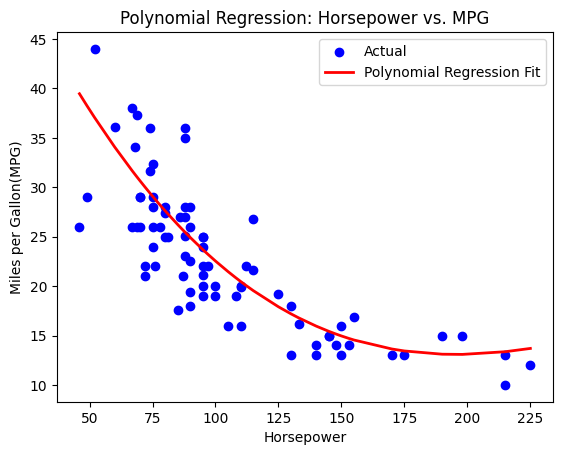

In [14]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2, label='Polynomial Regression Fit')
plt.xlabel('Horsepower')
plt.ylabel('Miles per Gallon(MPG)')
plt.title('Polynomial Regression: Horsepower vs. MPG')
plt.legend()
plt.show()

In [15]:
print(f'Mean Squared Error: {mse_poly}')
print(f'R2 Score: {r2_poly}')

Mean Squared Error: 18.460267222145088
R2 Score: 0.6383217814069444


In [16]:
def run_models():
  polynomial_regression_auto_mpg()
run_models()